# Temporary Notebook for testing ContourGraph and RegionSlice creation


In [1]:
from collections import defaultdict
from collections import Counter

import pandas as pd
from shapely.geometry import Polygon


In [2]:
# Local functions and classes
from types_and_classes import *
from utilities import *
from contours import *
from contour_plotting import *

from contour_graph import *
from debug_tools import *
#from structures import *
from region_slice import *
from structure_set import *
from relations import *


In [3]:
%matplotlib inline

# RegionSlice requirements
- The RegionIndexes used as keys in the dictionary attributes should match across slices as much as possible.
- region MultiPolygons should include islands or relations might mistakenly identify a ring as overlapping whin it is interior to a shell, but exterior to an island.
- boundaries must be kept separate even if they are related to the same region.
- every contour of a given ROI on the same slice should be in the same RegionSlice

In [4]:
def surrounds_example3():
    box10x5 = box_points(10,5)
    circle4_left = circle_points(2, offset_x=-3)
    circle3_right = circle_points(1.5, offset_x=3)
    circle2_left = circle_points(1, offset_x=-3, offset_y=0.5)
    circle2_right = circle_points(1, offset_x=3)
    slice_data = [
        ContourPoints(box10x5, roi=0, slice_index=1.0),
        ContourPoints(circle4_left, roi=0, slice_index=1.0),
        ContourPoints(circle3_right, roi=0, slice_index=1.0),
        ContourPoints(circle2_right, roi=0, slice_index=1.0),
        ContourPoints(circle2_left, roi=1, slice_index=1.0),
        ]
    contour_table, slice_sequence = build_contour_table(slice_data)
    contour_graph_a, slice_sequence = build_contour_graph(contour_table,
                                                        slice_sequence,
                                                        roi=0)
    contour_graph_b, slice_sequence = build_contour_graph(contour_table,
                                                        slice_sequence,
                                                        roi=1)
    region_slice_a = RegionSlice(contour_graph_a, slice_index=1.0)
    region_slice_b = RegionSlice(contour_graph_b, slice_index=1.0)
    return region_slice_a, region_slice_b


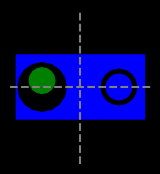

|001|	|001|	|111|
|001|	|001|	|001|
|111|	|111|	|001|

Relationship: Shelters


In [5]:

a, b = surrounds_example3()
ax = plot_ab(a.regions['0A'], b.regions['1A'])
plt.show()

r = DE27IM(a,b)

print(str(r))
print(r.identify_relation())

## *Surrounds* vs *Shelters* 
- This one is *Surrounds* because the holes are closed.

In [6]:
box10x5 = box_points(10,5)
circle4_left = circle_points(2, offset_x=-3)
circle3_right = circle_points(1.5, offset_x=3)
circle2_left = circle_points(1, offset_x=-3, offset_y=0.5)
circle2_right = circle_points(1, offset_x=3)
slice_data = [
    ContourPoints(box10x5, roi=0, slice_index=-2.0),
    ContourPoints(box10x5, roi=0, slice_index=-1.0),
    ContourPoints(box10x5, roi=0, slice_index=0.0),
    ContourPoints(box10x5, roi=0, slice_index=1.0),
    ContourPoints(box10x5, roi=0, slice_index=2.0),
    ContourPoints(box10x5, roi=0, slice_index=3.0),
    ContourPoints(box10x5, roi=0, slice_index=4.0),

    ContourPoints(circle4_left, roi=0, slice_index=0.0),
    ContourPoints(circle4_left, roi=0, slice_index=1.0),
    ContourPoints(circle4_left, roi=0, slice_index=2.0),

    ContourPoints(circle3_right, roi=0, slice_index=0.0),
    ContourPoints(circle3_right, roi=0, slice_index=1.0),
    ContourPoints(circle3_right, roi=0, slice_index=2.0),

    ContourPoints(circle2_right, roi=0, slice_index=0.0),
    ContourPoints(circle2_right, roi=0, slice_index=1.0),
    ContourPoints(circle2_right, roi=0, slice_index=2.0),

    ContourPoints(circle2_left, roi=1, slice_index=0.0),
    ContourPoints(circle2_left, roi=1, slice_index=1.0),
    ContourPoints(circle2_left, roi=1, slice_index=2.0)

]

contour_table, slice_sequence = build_contour_table(slice_data)


#### Patch Note: 
- Was crashing here because a boundary contour was already created for a contour and then it tries to create a second boundary contour for the same contour.
- Added a try/except to handle this case.
- This is a temporary fix, but it should be removed once the boundary identification is fixed.

In [7]:
contour_graph_a, slice_sequence = build_contour_graph(contour_table,
                                                    slice_sequence,
                                                    roi=0)
contour_graph_b, slice_sequence = build_contour_graph(contour_table,
                                                    slice_sequence,
                                                    roi=1)

In [8]:
a = RegionSlice(contour_graph_a, slice_index=1.0)
b = RegionSlice(contour_graph_b, slice_index=1.0)

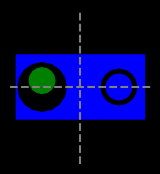

|001|	|111|	|111|
|001|	|001|	|001|
|111|	|001|	|001|

Relationship: Surrounds


In [9]:
ax = plot_ab(a.regions['0A'], b.regions['1A'])

r = DE27IM(a,b)

print(str(r))
print(r.identify_relation())

- This one is *Shelters* because the holes are open.

In [10]:
box10x5 = box_points(10,5)
circle4_left = circle_points(2, offset_x=-3)
circle3_right = circle_points(1.5, offset_x=3)
circle2_left = circle_points(1, offset_x=-3, offset_y=0.5)
circle2_right = circle_points(1, offset_x=3)
slice_data = [
    ContourPoints(box10x5, roi=0, slice_index=0.0),
    ContourPoints(box10x5, roi=0, slice_index=1.0),
    ContourPoints(box10x5, roi=0, slice_index=2.0),

    ContourPoints(circle4_left, roi=0, slice_index=0.0),
    ContourPoints(circle4_left, roi=0, slice_index=1.0),
    ContourPoints(circle4_left, roi=0, slice_index=2.0),

    ContourPoints(circle3_right, roi=0, slice_index=0.0),
    ContourPoints(circle3_right, roi=0, slice_index=1.0),
    ContourPoints(circle3_right, roi=0, slice_index=2.0),

    ContourPoints(circle2_right, roi=0, slice_index=0.0),
    ContourPoints(circle2_right, roi=0, slice_index=1.0),
    ContourPoints(circle2_right, roi=0, slice_index=2.0),

    ContourPoints(circle2_left, roi=1, slice_index=0.0),
    ContourPoints(circle2_left, roi=1, slice_index=1.0),
    ContourPoints(circle2_left, roi=1, slice_index=2.0)

]

contour_table, slice_sequence = build_contour_table(slice_data)


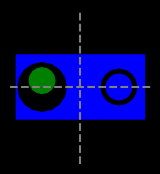

|001|	|111|	|111|
|001|	|001|	|001|
|111|	|001|	|001|

Relationship: Surrounds


In [11]:
contour_graph_a, slice_sequence = build_contour_graph(contour_table,
                                                    slice_sequence,
                                                    roi=0)
contour_graph_b, slice_sequence = build_contour_graph(contour_table,
                                                    slice_sequence,
                                                    roi=1)
a = RegionSlice(contour_graph_a, slice_index=1.0)
b = RegionSlice(contour_graph_b, slice_index=1.0)
ax = plot_ab(a.regions['0A'], b.regions['1A'])

r = DE27IM(a,b)

print(str(r))
print(r.identify_relation())

# Using degree = 1 to identify boundaries will miss some boundaries
- If there is a bifurcation in the contour on the slice before the boundary the degree will be 2, for a boundary contour.
- degree = 1 is a sufficient to identify boundaries, but not a necessary condition for a boundary.
- if degree > 1, but all edges point in the same (SliceIndex) direction, then it is also a boundary.

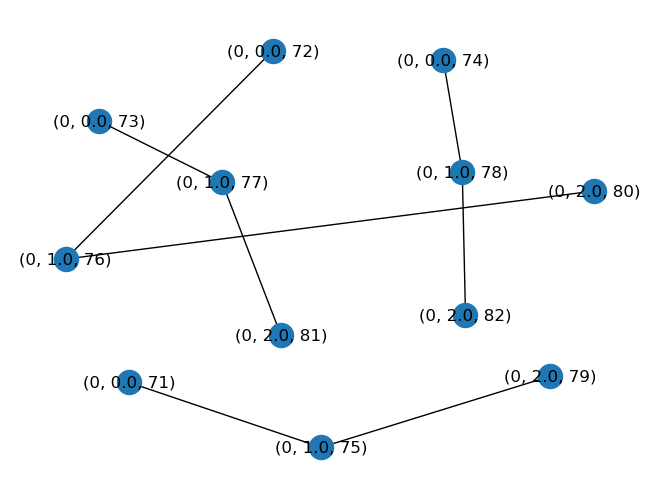

In [12]:
contour_graph = nx.Graph()
roi=0
contour_by_slice = build_contours(contour_table, roi)
for contour_data in contour_by_slice.values():
        for contour in contour_data:
            contour_label = contour.index
            contour_graph.add_node(contour_label, contour=contour)
contour_graph = add_graph_edges(contour_graph, slice_sequence)

nx.draw(contour_graph, with_labels=True,
           pos=nx.arf_layout(contour_graph))
plt.show()

In [13]:
contour_lookup = build_contour_lookup(contour_graph)

contour_lookup.loc[contour_lookup.ROI==0, ['SliceIndex', 'HoleType', 'Label']]

,SliceIndex,HoleType,Label
0,0.0,None,"(0, 0.0, 71)"
1,0.0,Unknown,"(0, 0.0, 72)"
2,0.0,Unknown,"(0, 0.0, 73)"
3,0.0,None,"(0, 0.0, 74)"
4,1.0,None,"(0, 1.0, 75)"
5,1.0,Unknown,"(0, 1.0, 76)"
6,1.0,Unknown,"(0, 1.0, 77)"
7,1.0,None,"(0, 1.0, 78)"
8,2.0,None,"(0, 2.0, 79)"
9,2.0,Unknown,"(0, 2.0, 80)"


In [14]:
[(node, degree) for node, degree in contour_graph.degree()]

[((0, 0.0, 71), 1),
 ((0, 0.0, 72), 1),
 ((0, 0.0, 73), 1),
 ((0, 0.0, 74), 1),
 ((0, 1.0, 75), 2),
 ((0, 1.0, 76), 2),
 ((0, 1.0, 77), 2),
 ((0, 1.0, 78), 2),
 ((0, 2.0, 79), 1),
 ((0, 2.0, 80), 1),
 ((0, 2.0, 81), 1),
 ((0, 2.0, 82), 1)]

In [15]:
boundary_nodes = {node for node, degree in contour_graph.degree()
                    if degree == 1}
boundary_nodes

{(0, 0.0, 71),
 (0, 0.0, 72),
 (0, 0.0, 73),
 (0, 0.0, 74),
 (0, 2.0, 79),
 (0, 2.0, 80),
 (0, 2.0, 81),
 (0, 2.0, 82)}

In [16]:
box10x5 = box_points(10,5)

circle6 = circle_points(3)
circle5 = circle_points(2.5)
circle4 = circle_points(2)
circle3 = circle_points(1.5)
circle2 = circle_points(1)
slice_data = [
    ContourPoints(circle6, roi=0, slice_index=-2.0),
    ContourPoints(circle6, roi=0, slice_index=-1.0),
    ContourPoints(circle6, roi=0, slice_index=0.0),
    ContourPoints(circle6, roi=0, slice_index=1.0),
    ContourPoints(circle6, roi=0, slice_index=2.0),
    ContourPoints(circle6, roi=0, slice_index=3.0),
    ContourPoints(circle6, roi=0, slice_index=4.0),

    ContourPoints(circle5, roi=0, slice_index=0.0),
    ContourPoints(circle5, roi=0, slice_index=1.0),
    ContourPoints(circle5, roi=0, slice_index=2.0),

    ContourPoints(circle2, roi=0, slice_index=0.0),
    ContourPoints(circle2, roi=0, slice_index=1.0),
    ContourPoints(circle2, roi=0, slice_index=2.0),

    ContourPoints(circle4, roi=1, slice_index=0.0),
    ContourPoints(circle4, roi=1, slice_index=1.0),
    ContourPoints(circle4, roi=1, slice_index=2.0),

    ContourPoints(circle3, roi=1, slice_index=0.0),
    ContourPoints(circle3, roi=1, slice_index=1.0),
    ContourPoints(circle3, roi=1, slice_index=2.0),
]
contour_table, slice_sequence = build_contour_table(slice_data)
contour_graph_a, slice_sequence = build_contour_graph(contour_table,
                                                    slice_sequence,
                                                    roi=0)
contour_graph_b, slice_sequence = build_contour_graph(contour_table,
                                                    slice_sequence,
                                                    roi=1)
a = RegionSlice(contour_graph_a, slice_index=1.0)
b = RegionSlice(contour_graph_b, slice_index=1.0)


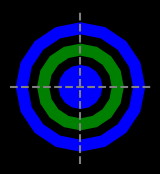

In [17]:
ax = plot_ab(a.regions['0A'], b.regions['1A'])


In [18]:

r = DE27IM(a,b)

print(str(r))
print(r.identify_relation())


|001|	|111|	|111|
|001|	|001|	|001|
|111|	|001|	|001|

Relationship: Surrounds


## Two regions at boundary of one of them
Box1 and box2 are offset horizontally (x = -5, x = +5), but overlap 
vertically (slices 0 to 4) vs (slices -3 to 1)
The contained_box is inside box2.
A boundary slice should be created Create two non-overlapping boxes on the same slice, force same region index
        

In [19]:
box1 = box_points(width=4, offset_x=-5)
box2 = box_points(width=2, offset_x=2.5)
box3 = box_points(width=2, offset_x=5)

contained_box = box_points(width=2, offset_x=-5)
slice_data = [
    ContourPoints(box1, roi=1, slice_index=0.0),
    ContourPoints(box1, roi=1, slice_index=1.0),
    ContourPoints(box1, roi=1, slice_index=2.0),
    ContourPoints(box1, roi=1, slice_index=3.0),
    ContourPoints(box1, roi=1, slice_index=4.0),
    ContourPoints(box2, roi=1, slice_index=1.0),
    ContourPoints(box2, roi=1, slice_index=0.0),
    ContourPoints(box2, roi=1, slice_index=-1.0),
    ContourPoints(box2, roi=1, slice_index=-2.0),
    ContourPoints(box2, roi=1, slice_index=-3.0),
    ContourPoints(box3, roi=1, slice_index=1.0),
    ContourPoints(box3, roi=1, slice_index=0.0),
    ContourPoints(box3, roi=1, slice_index=-1.0),
    ContourPoints(box3, roi=1, slice_index=-2.0),
    ContourPoints(box3, roi=1, slice_index=-3.0),
    ContourPoints(contained_box, roi=2, slice_index=0.0),
    ContourPoints(contained_box, roi=2, slice_index=-1.0),
    ContourPoints(contained_box, roi=2, slice_index=-2.0),
]
structure_set = StructureSet(slice_data)

INFO:structure_set:Adding structure Structure_1 (1)
INFO:structure_set:Adding structure Structure_2 (2)
INFO:structure_set:Calculating relationships for 2 structures
INFO:structure_set:Calculated relationships between Structure_1 (ROI 1) and Structure_2 (ROI 2) as: Overlaps
INFO:structure_set:Calculating logical flags for relationships
INFO:structure_set:Logical flag calculation complete


In [20]:
#structure_set.slice_sequence.sequence
structure_set.slice_sequence.sequence.at[-0.5,'Original']

np.False_

# ERROR Slice -0.5 should contain contours for both regions, but only contains contours for the boundary region.

<Axes: title={'center': 'Structure_1 vs Structure_2 at slice -1'}>

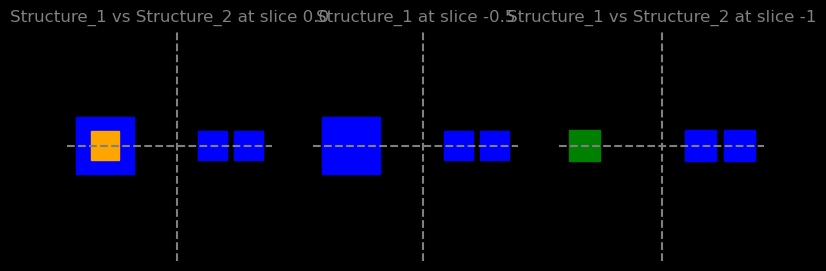

In [21]:
fig, ax = plt.subplots(1, 3, figsize=(9, 3))
plot_roi_slice(structure_set, slice_index=0.0, roi_list=[1, 2], add_axis=True,
               axes=ax[0])
plot_roi_slice(structure_set, slice_index=-0.5, roi_list=[1], add_axis=True,
               axes=ax[1])
plot_roi_slice(structure_set, slice_index=-1, roi_list=[1,2], add_axis=True,
               axes=ax[2])

In [22]:
region_slice = structure_set.structures[1].get_slice(-0.5)

In [23]:
region_slice.boundaries

{'1C': <MULTIPOLYGON Z (((-3 2 -0.5, -3 -2 -0.5, -7 -2 -0.5, -7 2 -0.5, -3 2 -0.5)))>,
 '1B': <MULTIPOLYGON EMPTY>,
 '1A': <MULTIPOLYGON EMPTY>}

In [24]:
region_slice.regions

{'1C': <MULTIPOLYGON EMPTY>,
 '1B': <MULTIPOLYGON Z (((6 1 -0.5, 6 -1 -0.5, 4 -1 -0.5, 4 1 -0.5, 6 1 -0.5)))>,
 '1A': <MULTIPOLYGON Z (((3.5 1 -0.5, 3.5 -1 -0.5, 1.5 -1 -0.5, 1.5 1 -0.5, 3.5 1 -...>}

In [25]:
region_slice.contour_indexes

{'1C': [(np.int64(1), -0.5, 131)],
 '1B': [(np.int64(1), -0.5, 143)],
 '1A': [(np.int64(1), -0.5, 142)]}

In [26]:
region_slice.hull

{'1C': <MULTIPOLYGON EMPTY>,
 '1B': <MULTIPOLYGON Z (((4 -1 -0.5, 4 1 -0.5, 6 1 -0.5, 6 -1 -0.5, 4 -1 -0.5)))>,
 '1A': <MULTIPOLYGON Z (((1.5 -1 -0.5, 1.5 1 -0.5, 3.5 1 -0.5, 3.5 -1 -0.5, 1.5 -1 ...>}

In [27]:
region_slice1 = structure_set.structures[1].get_slice(-1)
region_slice1.hull

{'1B': <MULTIPOLYGON Z (((4 -1 -1, 4 1 -1, 6 1 -1, 6 -1 -1, 4 -1 -1)))>,
 '1A': <MULTIPOLYGON Z (((1.5 -1 -1, 1.5 1 -1, 3.5 1 -1, 3.5 -1 -1, 1.5 -1 -1)))>}

In [28]:
region_slice0 = structure_set.structures[1].get_slice(0)
region_slice0.hull

{'1C': <MULTIPOLYGON Z (((-7 -2 0, -7 2 0, -3 2 0, -3 -2 0, -7 -2 0)))>,
 '1B': <MULTIPOLYGON Z (((4 -1 0, 4 1 0, 6 1 0, 6 -1 0, 4 -1 0)))>,
 '1A': <MULTIPOLYGON Z (((1.5 -1 0, 1.5 1 0, 3.5 1 0, 3.5 -1 0, 1.5 -1 0)))>}

In [29]:
region_slice0.contour_indexes

{'1C': [(np.int64(1), 0.0, 120)],
 '1B': [(np.int64(1), 0.0, 122)],
 '1A': [(np.int64(1), 0.0, 121)]}